In [39]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import config
import concordance
import pipeline
importlib.reload(config)
importlib.reload(concordance)
importlib.reload(pipeline)

# ── Display active parameters ─────────────────────────────────────────────────
# Edit config.py to change any of these — no changes to this notebook needed.
print("=" * 55)
print("TARIFF PCE PIPELINE — ACTIVE CONFIGURATION")
print("=" * 55)
rows = [
    ("BEA IO year",             config.IO_YEAR),
    ("Leontief source",         config.LEONTIEF_SOURCE),
    ("Concordance method",      config.CONCORDANCE_METHOD),
    ("BEA concordance file",    config.BEA_CONCORDANCE_FILE or "(none)"),
    (
        "Fallback unmapped NAICS",
        config.CONCORDANCE_FALLBACK_TO_MANUAL_UNMAPPED,
    ),
    ("Tariff baseline year",    config.TARIFF_BASELINE_YEAR),
    ("Tariff current month",    config.TARIFF_CURRENT_MONTH),
    ("Markup assumption",       config.MARKUP_ASSUMPTION),
    ("Inflation measure",       config.INFLATION_MEASURE),
    ("Counterfactual baseline", config.COUNTERFACTUAL_BASELINE_MONTH),
    ("Excess inflation window", f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"),
    ("Excess current window",   f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"),
    ("Core goods categories",   len(config.CORE_GOODS_CATEGORIES)),
]
for label, val in rows:
    print(f"  {label:<30} {val}")
print("=" * 55)


TARIFF PCE PIPELINE — ACTIVE CONFIGURATION
  BEA IO year                    2022
  Leontief source                computed
  Concordance method             bea_file
  BEA concordance file           data/concordance/naics_to_bea_summary.csv
  Fallback unmapped NAICS        True
  Tariff baseline year           2024
  Tariff current month           2025-12
  Markup assumption              constant_dollar
  Inflation measure              core_pce
  Counterfactual baseline        2024-12
  Excess inflation window        2024–2024
  Excess current window          2024-12 → 2025-12
  Core goods categories          27


In [40]:
# ── Step 1: Direct import shares (m_i = imports / total supply) ──────────────
# Methodology §2 / BEA Supply Table 262

import_shares = pipeline.step1_import_shares(config.IO_YEAR, config.BEA_KEY)

print(f"Commodities: {len(import_shares)}")
print(f"Import share range: "
      f"{import_shares['import_share'].min():.4f} – {import_shares['import_share'].max():.4f}")
print(f"\nTop 10 by direct import share:")
print(
    import_shares.nlargest(10, 'import_share')
    [['BEA_code', 'BEA_descr', 'import_share']]
    .to_string(index=False)
)


Commodities: 54
Import share range: 0.0000 – 0.9817

Top 10 by direct import share:
BEA_code                                              BEA_descr  import_share
   Other Noncomparable imports and rest-of-the-world adjustment      0.981691
   315AL                Apparel and leather and allied products      0.896286
    Used                       Scrap, used and secondhand goods      0.628821
     334                       Computer and electronic products      0.561930
     335       Electrical equipment, appliances, and components      0.495563
     339                            Miscellaneous manufacturing      0.470299
   313TT                Textile mills and textile product mills      0.457732
     337                         Furniture and related products      0.428505
     333                                              Machinery      0.349592
  3361MV         Motor vehicles, bodies and trailers, and parts      0.338408


In [41]:
# ── Steps 2–3: Technical coefficients (A) and Leontief inverse (L) ───────────
# Methodology §3–4 / BEA Use Table 259
# config.LEONTIEF_SOURCE: "computed" (default) or "bea" (BEA TableID 59)

industries, A, L = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, config.LEONTIEF_SOURCE
)

I_n = np.eye(len(industries))
print(f"Industries: {len(industries)}")
print(f"A matrix shape:                  {A.shape}")
print(f"Max A column sum (must be < 1):  {A.sum(axis=0).max():.4f}")
print(f"Condition number of (I - A):     {np.linalg.cond(I_n - A):.1f}")
print(f"Leontief diagonal mean (> 1):    {np.diag(L).mean():.4f}")
print(f"L min value (should be ≥ 0):     {L.min():.4f}")


Leontief source: computed from (I - A)^{-1} via Use Table 259
Industries: 68
A matrix shape:                  (68, 68)
Max A column sum (must be < 1):  0.9079
Condition number of (I - A):     3.2
Leontief diagonal mean (> 1):    1.1124
L min value (should be ≥ 0):     0.0000


In [42]:
# ── Validation: compare computed L against BEA pre-computed Total Requirements ─
# BEA TableID 59 = Commodity-by-Commodity Total Requirements, Summary (= Leontief inverse)
# Differences should be very small (< 0.001), reflecting only BEA's internal
# rounding when publishing the pre-computed table.

val = pipeline.validate_leontief(config.IO_YEAR, config.BEA_KEY, industries, L)

print(f"Max absolute difference:  {val['max_abs_diff']:.6f}")
print(f"Mean absolute difference: {val['mean_abs_diff']:.6f}")
print(f"Max relative difference:  {val['max_rel_diff']:.4%}")
print(f"\nTop 10 largest element-wise differences:")
print(val["top_diffs"].to_string(index=False))


Max absolute difference:  0.219883
Mean absolute difference: 0.003983
Max relative difference:  1468.4211%

Top 10 largest element-wise differences:
row_industry col_industry  L_computed    L_bea  abs_diff
          42       3361MV    0.013796 0.233679  0.219883
       111CA        311FT    0.608512 0.397938  0.210573
          42        311FT    0.008617 0.191497  0.182880
          42          331    0.006493 0.188260  0.181768
          42          321    0.005595 0.159882  0.154287
          42          333    0.009400 0.159867  0.150468
          42        111CA    0.004966 0.152861  0.147896
          42          335    0.014657 0.158530  0.143872
          42          337    0.007329 0.148231  0.140902
          42          322    0.012027 0.146345  0.134318


In [43]:
# ── Step 4: Total import content (m_total = m' L) ────────────────────────────
# Methodology §5
# Supply-chain amplification: how much indirect imports add on top of direct shares.

m_vec, m_total = pipeline.step4_total_import_content(import_shares, industries, L)

print(f"Direct import shares mean:   {m_vec.mean():.4f}")
print(f"Total import content mean:   {m_total.mean():.4f}")
print(f"Supply-chain amplification:  {m_total.mean() / m_vec.mean():.2f}×")
print(f"\nSample — direct vs. total import content (first 15 industries):")
print(f"  {'Industry':<14}  {'Direct':>8}  {'Total':>8}  {'Ratio':>6}")
for i, ind in enumerate(industries[:15]):
    ratio = m_total[i] / m_vec[i] if m_vec[i] > 0 else float('nan')
    print(f"  {ind:<14}  {m_vec[i]:8.4f}  {m_total[i]:8.4f}  {ratio:6.2f}×")


Direct import shares mean:   0.1026
Total import content mean:   0.2232
Supply-chain amplification:  2.18×

Sample — direct vs. total import content (first 15 industries):
  Industry          Direct     Total   Ratio
  111CA             0.0907    0.2643    2.91×
  113FF             0.2433    0.3368    1.38×
  211               0.2901    0.4381    1.51×
  212               0.0628    0.1808    2.88×
  213               0.0107    0.0951    8.86×
  22                0.0055    0.0902   16.44×
  23                0.0000    0.1956     nan×
  311FT             0.1094    0.3332    3.04×
  313TT             0.4577    0.7946    1.74×
  315AL             0.8963    1.0369    1.16×
  321               0.1721    0.4112    2.39×
  322               0.1307    0.3563    2.73×
  323               0.0423    0.2223    5.26×
  324               0.0957    0.4031    4.21×
  325               0.2899    0.4692    1.62×


In [44]:
# ── Step 5: Δτ = τ_current − τ_baseline per BEA industry ─────────────────────
# Methodology §6
# Baseline: annual average over all 12 months of config.TARIFF_BASELINE_YEAR
# Current:  single month config.TARIFF_CURRENT_MONTH

delta_tariff_df = pipeline.step5_delta_tariff(
    config.IMPORTS_FILE,
    config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH,
    concordance_method=config.CONCORDANCE_METHOD,
    bea_concordance_file=(config.BEA_CONCORDANCE_FILE or None),
    fallback_to_manual_unmapped=config.CONCORDANCE_FALLBACK_TO_MANUAL_UNMAPPED,
)

print(f"BEA industries: {len(delta_tariff_df)}")
print(f"\nTop 10 by tariff increase (Δτ):")
print(
    delta_tariff_df.nlargest(10, 'delta_tariff')
    [['bea_io', 'bea_desc', 'tau_base', 'tau', 'delta_tariff']]
    .to_string(index=False)
)


Concordance built (bea_file): 383/388 NAICS6 codes mapped to BEA IO industries
  Manual fallback used for 9 unmapped NAICS6 codes
  Out of scope (services/unmapped): 5 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 93.5% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
BEA industries: 24

Top 10 by tariff increase (Δτ):
bea_io                                         bea_desc  tau_base      tau  delta_tariff
   332                        Fabricated metal products  0.059009 0.284990      0.225981
 313TT          Textile mills and textile product mills  0.079974 0.272518      0.192544
   337                   Furniture and related products  

In [45]:
# ── Concordance check: compare manual vs bea_file outputs ─────────────────────
# This lets you see exactly what changes when you switch concordance sources.

# Toggle to compare strict external-only mapping vs. fallback-to-manual mode.
fallback_unmapped = config.CONCORDANCE_FALLBACK_TO_MANUAL_UNMAPPED

if not config.BEA_CONCORDANCE_FILE:
    print("Set config.BEA_CONCORDANCE_FILE to enable manual vs bea_file comparison.")
else:
    d_manual = pipeline.step5_delta_tariff(
        config.IMPORTS_FILE,
        config.TARIFF_BASELINE_YEAR,
        config.TARIFF_CURRENT_MONTH,
        concordance_method="manual",
    )
    d_bea = pipeline.step5_delta_tariff(
        config.IMPORTS_FILE,
        config.TARIFF_BASELINE_YEAR,
        config.TARIFF_CURRENT_MONTH,
        concordance_method="bea_file",
        bea_concordance_file=config.BEA_CONCORDANCE_FILE,
        fallback_to_manual_unmapped=fallback_unmapped,
    )

    comp = d_manual[["bea_io", "bea_desc", "delta_tariff", "tau_base", "tau"]].merge(
        d_bea[["bea_io", "delta_tariff", "tau_base", "tau"]],
        on="bea_io",
        how="outer",
        suffixes=("_manual", "_bea"),
    )
    comp["delta_diff_pp"] = (comp["delta_tariff_bea"] - comp["delta_tariff_manual"]) * 100
    comp["tau_base_diff_pp"] = (comp["tau_base_bea"] - comp["tau_base_manual"]) * 100
    comp["tau_curr_diff_pp"] = (comp["tau_bea"] - comp["tau_manual"]) * 100

    print(
        "Top 15 industries by absolute Δτ change "
        f"(bea_file fallback={fallback_unmapped} - manual), percentage points:"
    )
    print(
        comp.reindex(comp["delta_diff_pp"].abs().sort_values(ascending=False).index)
        [["bea_io", "bea_desc", "delta_tariff_manual", "delta_tariff_bea", "delta_diff_pp"]]
        .head(15)
        .to_string(index=False, float_format=lambda x: f"{x:.4f}")
    )

    print("\nSummary of concordance-induced Δτ changes (pp):")
    print(comp["delta_diff_pp"].describe().to_string())


Concordance built (manual): 379/388 NAICS6 codes mapped to BEA IO industries
  Out of scope (services/unmapped): 9 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 93.5% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
Concordance built (bea_file): 383/388 NAICS6 codes mapped to BEA IO industries
  Manual fallback used for 9 unmapped NAICS6 codes
  Out of scope (services/unmapped): 5 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value 

In [46]:
# ── PCE Bridge + Step 6: Predicted tariff effect per PCE category ─────────────
# Methodology §7
# Markup assumption (config.MARKUP_ASSUMPTION):
#   "constant_dollar"  → numerator weighted by producers' value (Fed conservative baseline)
#   "constant_percent" → numerator weighted by purchasers' value (larger consumer effect)

pce_bridge    = pipeline.load_pce_bridge(config.IO_YEAR, config.BEA_KEY)
pce_effect_df = pipeline.step6_pce_effect(
    industries      = industries,
    m_vec           = m_vec,
    L               = L,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge,
    markup          = config.MARKUP_ASSUMPTION,
)

print(f"Markup assumption: {config.MARKUP_ASSUMPTION}")
print(f"\nTop 15 PCE categories by predicted tariff effect:")
print(
    pce_effect_df.head(15)[['PCE_category', 'predicted_effect']]
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

# Weighted-average effect on core goods — carried forward to counterfactual cells
core = pce_effect_df.query('PCE_category in @config.CORE_GOODS_CATEGORIES')
core_effect = (
    (core['predicted_effect'] * core['purchasers_value_total']).sum()
    / core['purchasers_value_total'].sum()
)
print(f"\nWeighted avg predicted effect — core goods: {core_effect:.2%}")


Markup assumption: constant_dollar

Top 15 PCE categories by predicted tariff effect:
                                      PCE_category  predicted_effect
                          Men's and boys' clothing            0.0633
                Luggage and similar personal items            0.0621
             Other clothing materials and footwear            0.0614
                       Women's and girls' clothing            0.0512
                                New motor vehicles            0.0499
                              Household appliances            0.0467
                               Musical instruments            0.0437
                         Furniture and furnishings            0.0356
      Glassware, tableware, and household utensils            0.0326
                  Sports and recreational vehicles            0.0289
                  Children's and infants' clothing            0.0272
Sporting equipment, supplies, guns, and ammunition            0.0266
               Mo

In [47]:
# ── Method impact check: compare PCE effects across concordance methods ───────
# This quantifies how switching concordance affects downstream category-level results.

fallback_unmapped = config.CONCORDANCE_FALLBACK_TO_MANUAL_UNMAPPED

if not config.BEA_CONCORDANCE_FILE:
    print("Set config.BEA_CONCORDANCE_FILE to enable downstream method comparison.")
else:
    dt_manual = pipeline.step5_delta_tariff(
        config.IMPORTS_FILE,
        config.TARIFF_BASELINE_YEAR,
        config.TARIFF_CURRENT_MONTH,
        concordance_method="manual",
    )
    dt_bea = pipeline.step5_delta_tariff(
        config.IMPORTS_FILE,
        config.TARIFF_BASELINE_YEAR,
        config.TARIFF_CURRENT_MONTH,
        concordance_method="bea_file",
        bea_concordance_file=config.BEA_CONCORDANCE_FILE,
        fallback_to_manual_unmapped=fallback_unmapped,
    )

    pce_manual = pipeline.step6_pce_effect(
        industries=industries,
        m_vec=m_vec,
        L=L,
        delta_tariff_df=dt_manual,
        pce_bridge=pce_bridge,
        markup=config.MARKUP_ASSUMPTION,
    )
    pce_bea = pipeline.step6_pce_effect(
        industries=industries,
        m_vec=m_vec,
        L=L,
        delta_tariff_df=dt_bea,
        pce_bridge=pce_bridge,
        markup=config.MARKUP_ASSUMPTION,
    )

    pce_comp = pce_manual[["PCE_category", "predicted_effect", "purchasers_value_total"]].merge(
        pce_bea[["PCE_category", "predicted_effect"]],
        on="PCE_category",
        how="outer",
        suffixes=("_manual", "_bea"),
    )
    pce_comp["effect_diff_pp"] = (
        pce_comp["predicted_effect_bea"] - pce_comp["predicted_effect_manual"]
    ) * 100

    print(
        "Top 15 PCE categories by absolute predicted-effect change "
        f"(bea_file fallback={fallback_unmapped} - manual), pp:"
    )
    print(
        pce_comp.reindex(pce_comp["effect_diff_pp"].abs().sort_values(ascending=False).index)
        [["PCE_category", "predicted_effect_manual", "predicted_effect_bea", "effect_diff_pp"]]
        .head(15)
        .to_string(index=False, float_format=lambda x: f"{x:.4f}")
    )

    def _core_effect(df):
        core_df = df.query("PCE_category in @config.CORE_GOODS_CATEGORIES")
        return (
            (core_df["predicted_effect"] * core_df["purchasers_value_total"]).sum()
            / core_df["purchasers_value_total"].sum()
        )

    core_manual = _core_effect(pce_manual)
    core_bea = _core_effect(pce_bea)
    print("\nCore-goods weighted predicted effect:")
    print(f"  manual:   {core_manual:.2%}")
    print(f"  bea_file: {core_bea:.2%}")
    print(f"  diff:     {(core_bea - core_manual) * 100:.2f} pp")


Concordance built (manual): 379/388 NAICS6 codes mapped to BEA IO industries
  Out of scope (services/unmapped): 9 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 93.5% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
Concordance built (bea_file): 383/388 NAICS6 codes mapped to BEA IO industries
  Manual fallback used for 9 unmapped NAICS6 codes
  Out of scope (services/unmapped): 5 codes
  BEA IO industries covered: 23

Import value coverage: 94.6% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value 

In [48]:
# ── Worked example: trace full methodology chain for a single industry ────────
# Call pipeline.trace_industry() with any BEA IO code to see every step:
#   Step 1  — direct import share
#   Step 4  — total import content via Leontief (supply-chain amplification)
#   Step 5  — tariff change (Δτ) and predicted producer-level price effect
#   Step 6  — PCE bridge breakdown and final consumer-price effect
#
# All inputs come from the cells above — no recomputation needed.
# Change BEA_CODE to trace any industry (e.g. '3364OT', '3360OP', '3330SS').

BEA_CODE = "3361MV"   # Motor vehicles, bodies and trailers, and parts

pipeline.trace_industry(
    bea_code        = BEA_CODE,
    import_shares   = import_shares,
    industries      = industries,
    L               = L,
    m_vec           = m_vec,
    m_total         = m_total,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge,
    pce_effect_df   = pce_effect_df,
    markup          = config.MARKUP_ASSUMPTION,
)

────────────────────────────────────────────────────────────────
  INDUSTRY TRACE  ·  3361MV  —  Motor vehicles, bodies and trailers, and parts
────────────────────────────────────────────────────────────────

Step 1  —  Direct import share  (m_i = imports / total supply)
  imports       =       353,470  ($M)
  total supply  =     1,044,509  ($M)
  m_i           =         33.8%

Step 4  —  Total import content via Leontief  (m̃_j = m′ L)
  direct m_i     =         33.8%  (imports at the border)
  total m̃_j      =         80.4%  (direct + all upstream tiers)
  indirect share =         46.6%  (embedded in domestic inputs)
  amplification  =          2.38×

Step 5  —  Import tariff change  (Δτ = τ_current − τ_baseline)
  τ_baseline  =          1.9%
  τ_current   =         14.4%
  Δτ          =        +12.5%

Step 5  —  Predicted producer-level price effect  (p̂_j = Σ_i m_i·Δτ_i·L_ij)
  p̂_j             =          9.3%
  Naive approx    =         10.0%  (m̃_j × Δτ_j, ignores upstream tari

In [49]:
# ── Step 7a: Monthly counterfactual (NIPA T20804) ────────────────────────────
# Methodology §8
# config.INFLATION_MEASURE: "core_pce" (PCE ex food & energy) or "headline_pce"
# For the core-goods quarterly index, see Cell 8.

if config.INFLATION_MEASURE == "core_goods_pce":
    print("INFLATION_MEASURE = 'core_goods_pce' — skipping monthly counterfactual.")
    print("The quarterly core-goods counterfactual is computed in Cell 8.")
else:
    baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
    current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
    years       = sorted({baseline_yr, current_yr})

    inflation_series = pipeline.step7_load_inflation(
        config.INFLATION_MEASURE, config.BEA_KEY, years
    )
    result = pipeline.step7_counterfactual(
        inflation_series      = inflation_series,
        pce_effect_df         = pce_effect_df,
        baseline_month        = config.COUNTERFACTUAL_BASELINE_MONTH,
        current_month         = config.TARIFF_CURRENT_MONTH,
        core_goods_categories = config.CORE_GOODS_CATEGORIES,
        pce_bridge            = pce_bridge,
    )

    label = "Core PCE" if config.INFLATION_MEASURE == "core_pce" else "Headline PCE"
    print(f"{label}  ({config.COUNTERFACTUAL_BASELINE_MONTH} → {config.TARIFF_CURRENT_MONTH})")
    print(f"  Actual inflation:            {result['actual_inflation']:.2%}")
    print(f"  Core goods tariff effect:    {result['core_goods_effect']:.2%}")
    print(f"  Core goods share of PCE:     {result['core_goods_share']:.2%}")
    print(f"  Tariff contribution to PCE:  {result['tariff_contribution']:.2%}")
    print(f"  Counterfactual (no tariffs): {result['counterfactual_inflation']:.2%}")
    print("\nCoverage diagnostics:")
    print(f"  Modeled PCE coverage:        {result['modeled_pce_coverage']:.2%}")
    print(f"  Core-goods weight coverage:  {result['core_weight_coverage']:.2%}")
    if result['missing_core_categories']:
        print("  Missing core categories:")
        for cat in result['missing_core_categories']:
            print(f"    - {cat}")


Core PCE  (2024-12 → 2025-12)
  Actual inflation:            3.01%
  Core goods tariff effect:    2.44%
  Core goods share of PCE:     22.71%
  Tariff contribution to PCE:  0.55%
  Counterfactual (no tariffs): 2.45%

Coverage diagnostics:
  Modeled PCE coverage:        100.00%
  Core-goods weight coverage:  100.00%


In [50]:
# ── Step 7b: Monthly core-goods price index + counterfactual (NI Underlying Detail U20404) ──
# Methodology §8
# Constructs a PCE-weighted price index for the 27 core goods categories and
# computes the counterfactual baseline → current-month inflation (no tariff scenario).

import requests

baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
years       = sorted({baseline_yr, current_yr})
year_str    = ",".join(str(y) for y in years)

r = requests.get(
    "https://apps.bea.gov/api/data"
    f"?UserID={config.BEA_KEY}"
    "&method=GetData"
    "&DataSetName=NIUnderlyingDetail"
    "&TableName=U20404"
    "&Frequency=M"
    f"&Year={year_str}"
    "&ResultFormat=json"
)
r.raise_for_status()
pce_monthly = pd.DataFrame(r.json()["BEAAPI"]["Results"]["Data"])
pce_monthly["DataValue"] = pd.to_numeric(pce_monthly["DataValue"], errors="coerce")

core_goods_index = pipeline.step7_core_goods_index_monthly(
    pce_monthly_df        = pce_monthly,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
)

baseline_m = config.COUNTERFACTUAL_BASELINE_MONTH   # e.g. "2024-12"
current_m  = config.TARIFF_CURRENT_MONTH            # e.g. "2025-12"
idx_base   = core_goods_index[baseline_m]
idx_latest = core_goods_index[current_m]

actual_cg_inflation = (idx_latest - idx_base) / idx_base
counterfactual_cg   = actual_cg_inflation - core_effect

print("Core goods price index (monthly):")
print(core_goods_index.to_string())
print(f"\nActual core goods inflation ({baseline_m} → {current_m}):  {actual_cg_inflation:.2%}")
print(f"Predicted tariff contribution:                            {core_effect:.2%}")
print(f"Counterfactual (no tariffs):                              {counterfactual_cg:.2%}")


Core goods price index (monthly):
TimePeriod
2024-01    109.413581
2024-02    109.706970
2024-03    109.776552
2024-04    109.797788
2024-05    109.646220
2024-06    109.648313
2024-07    109.531636
2024-08    109.412643
2024-09    109.493235
2024-10    109.664699
2024-11    109.609787
2024-12    109.405979
2025-01    109.857185
2025-02    110.268239
2025-03    110.016909
2025-04    110.227294
2025-05    110.516772
2025-06    110.904422
2025-07    110.994205
2025-08    111.060040
2025-09    111.302532
2025-10    111.354655
2025-11    111.374947
2025-12    111.692392

Actual core goods inflation (2024-12 → 2025-12):  2.09%
Predicted tariff contribution:                            2.44%
Counterfactual (no tariffs):                              -0.35%


In [51]:
current_year = int(config.TARIFF_CURRENT_MONTH[:4])

summary_df = pipeline.step7_excess_inflation(
    api_key               = config.BEA_KEY,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
    current_start_month   = config.EXCESS_CURRENT_START_MONTH,
    current_end_month     = config.EXCESS_CURRENT_END_MONTH,
    baseline_start        = config.EXCESS_BASELINE_START,
    baseline_end          = config.EXCESS_BASELINE_END,
)


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.107
Model:                            WLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     3.009
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0951
Time:                        11:37:15   Log-Likelihood:                -67.506
No. Observations:                  27   AIC:                             139.0
Df Residuals:                      25   BIC:                             141.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2571      0.768      4.239      0.0

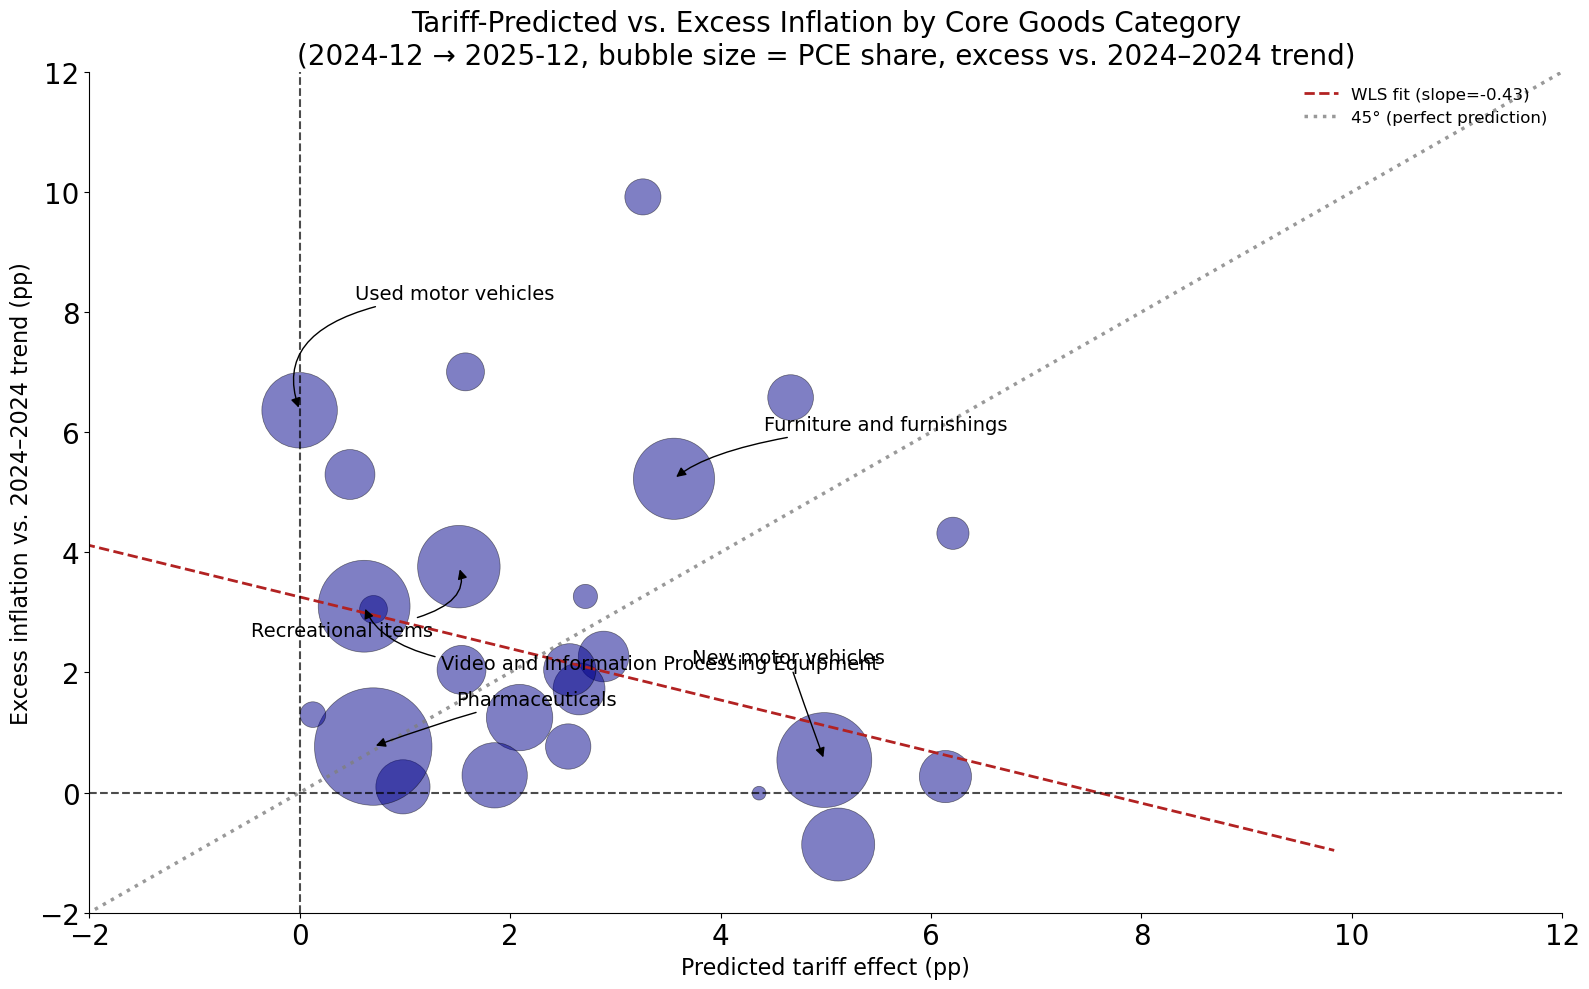

In [52]:

# ── Step 7c: Predicted tariff effect vs. excess inflation — scatter plot ──────
# Methodology §9
# Excess inflation = growth over the current window minus mean over the baseline window.
# Current window:  config.EXCESS_CURRENT_START_MONTH → config.EXCESS_CURRENT_END_MONTH
# Baseline window: config.EXCESS_BASELINE_START – config.EXCESS_BASELINE_END (inclusive).
# To adjust, change those values in config.py.


# print(
#     summary_df[['PCE_category', 'predicted_effect', 'excess_inflation', 'pce_share']]
#     .to_string(index=False)
# )

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
plot_df = summary_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share'])

ax.scatter(
    plot_df['predicted_effect'] * 100,
    plot_df['excess_inflation'] * 100,
    s=plot_df['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

x = plot_df['predicted_effect'].values * 100
y = plot_df['excess_inflation'].values * 100
w = plot_df['pce_share'].values

wls_model  = sm.WLS(y, sm.add_constant(x), weights=w).fit()
intercept, slope = wls_model.params
print(wls_model.summary())

x_fit = np.linspace(x.min() - 3.5, x.max() + 3.5, 100)
ax.plot(x_fit, slope * x_fit + intercept,
        color='firebrick', linewidth=2, linestyle='--',
        label=f'WLS fit (slope={slope:.2f})')


# 45° perfect-prediction line
_xy_min = min(x.min(), y.min()) - 3.05
_xy_max = max(x.max(), y.max()) + 3.05
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)


baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlim(-2.0, 12.0)
ax.set_ylim(-2.0, 12.0)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
# rank 0: Pharmaceutical and other medical products   xy=(0.70, -0.54)
# rank 1: New motor vehicles                          xy=(4.99,  0.13)
# rank 2: Video, audio, photographic, and info proc.  xy=(0.61,  9.13)
# rank 3: Recreational items                          xy=(1.50,  6.00)
# rank 4: Furniture and furnishings                   xy=(3.56,  5.68)
_top5 = plot_df.nlargest(5, "pce_share").reset_index(drop=True)

annotate_fontsize = 14

ax.annotate( # rank 0: pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5.loc[0, "predicted_effect"] * 100, _top5.loc[0, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 1: new motor vehicles
    _top5.loc[1, "PCE_category"],
    xy=(_top5.loc[1, "predicted_effect"] * 100, _top5.loc[1, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 2: video & info processing equipment
    "Video and Information Processing Equipment",  # Too long for the plot, so hardcoding a shorter label here
    xy=(_top5.loc[2, "predicted_effect"] * 100, _top5.loc[2, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(55, -45),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 3: recreational items
    _top5.loc[3, "PCE_category"],
    xy=(_top5.loc[3, "predicted_effect"] * 100, _top5.loc[3, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(-150, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 4: furniture & furnishings
    _top5.loc[4, "PCE_category"],
    xy=(_top5.loc[4, "predicted_effect"] * 100, _top5.loc[4, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate used motor vehicles ── xy=(0.00, 2.41) ───────────────────────────
_used_row = plot_df[plot_df['PCE_category'].str.contains('sed', case=False, na=False)].iloc[0]
ax.annotate(
    "Used motor vehicles",  # Too long for the plot, so hardcoding a shorter label here
    xy=(_used_row['predicted_effect'] * 100, _used_row['excess_inflation'] * 100),
    xycoords="data",
    xytext=(40, 80),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("tariff_vs_excess_inflation.png", bbox_inches="tight", dpi=150)
plt.show()


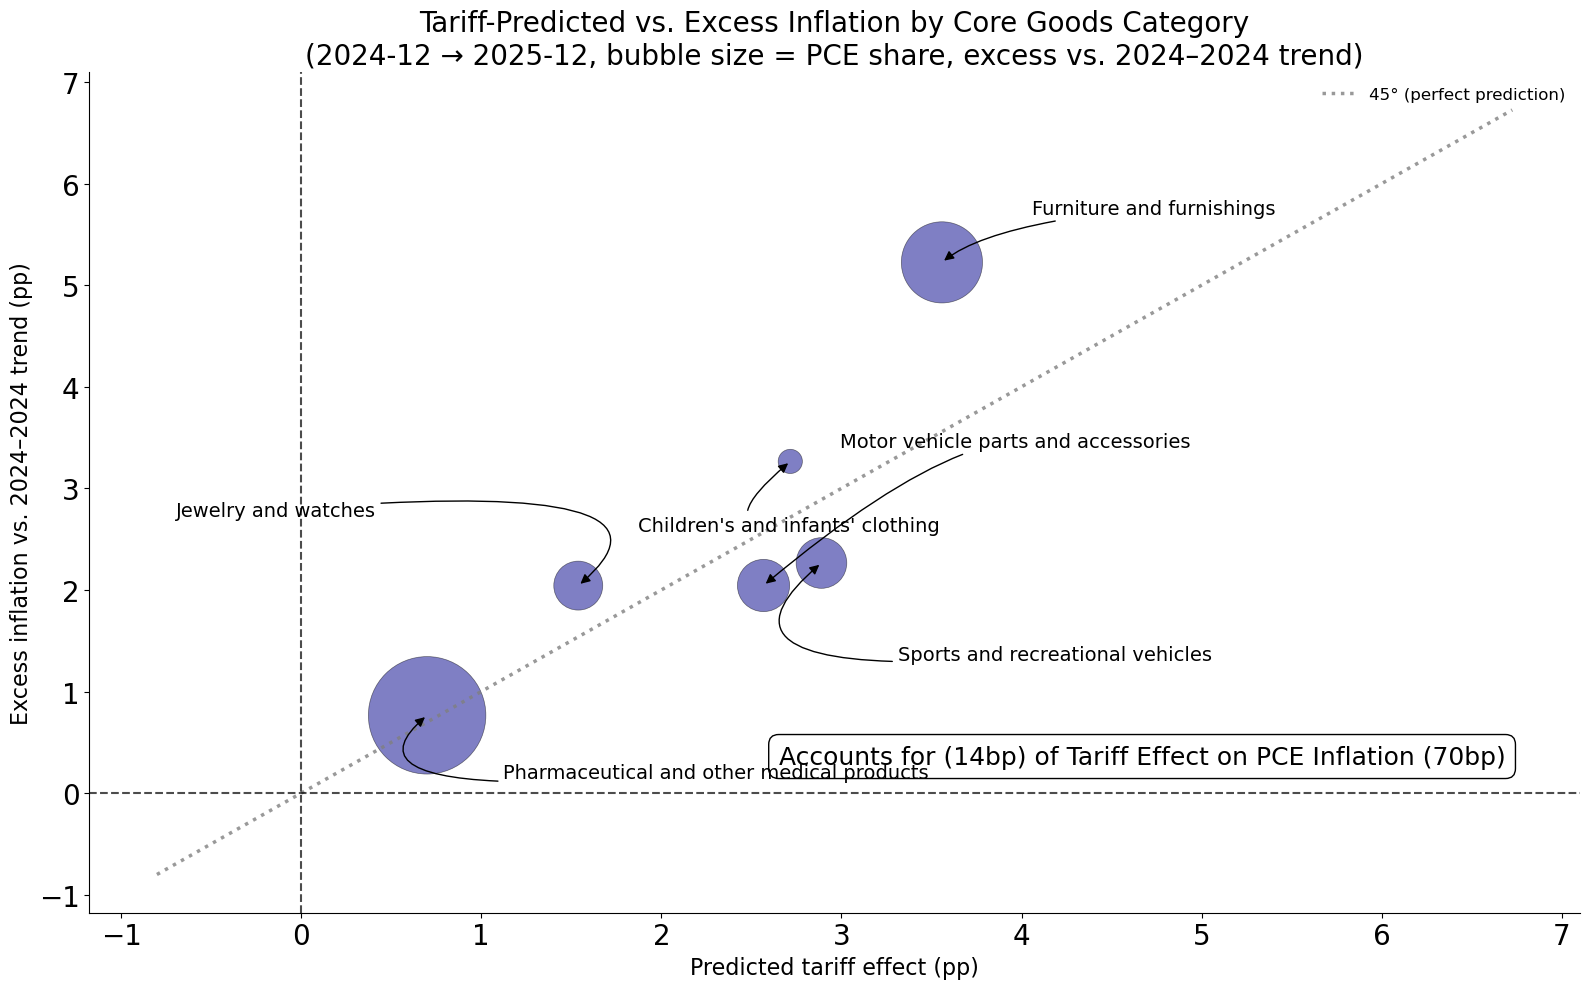

Furniture: Furniture and furnishings

Closest to 45° line:
                             PCE_category  predicted_effect  excess_inflation  _dist45
Pharmaceutical and other medical products          0.699580          0.766125 0.066545
                      Jewelry and watches          1.538759          2.042649 0.503889
      Motor vehicle parts and accessories          2.567317          2.043861 0.523456
         Children's and infants' clothing          2.715861          3.264884 0.549024
         Sports and recreational vehicles          2.888899          2.265252 0.623647


In [53]:

# ── Furniture + 5 closest to 45° line only — no other dots, no WLS ────────────

plot_df = summary_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share'])

# ── Select the 6 observations to plot ─────────────────────────────────────────
_furn_mask = plot_df['PCE_category'].str.contains('urniture', case=False, na=False)
_furn_row  = plot_df[_furn_mask].iloc[0]

_other = plot_df[~_furn_mask].copy()
_other['_dist45'] = (_other['excess_inflation'] * 100 - _other['predicted_effect'] * 100).abs()
_closest5 = _other.nsmallest(5, '_dist45').reset_index(drop=True)

# Slice the furniture row as a 1-row DataFrame (preserves dtypes)
_plot6 = pd.concat([plot_df[_furn_mask], _closest5.drop(columns='_dist45')], ignore_index=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

ax.scatter(
    _plot6['predicted_effect'] * 100,
    _plot6['excess_inflation'] * 100,
    s=_plot6['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

# 45° perfect-prediction line
_all_vals = pd.concat([_plot6['predicted_effect'], _plot6['excess_inflation']]) * 100
_xy_min = _all_vals.min() - 1.5
_xy_max = _all_vals.max() + 1.5
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

annotate_fontsize = 14

ax.text(
    0.95, 0.2,
    f"Accounts for (14bp) of Tariff Effect on PCE Inflation (70bp)",
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1),
)

# ── Annotate Furniture ── xy=(3.56, 5.68) ────────────────────────────────────
ax.annotate(
    _furn_row['PCE_category'],
    xy=(_furn_row['predicted_effect'] * 100, _furn_row['excess_inflation'] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate the 5 closest-to-45° categories ─────────────────────────────────
# rank 0: Personal care products            xy=(2.09, 2.16)
# rank 1: Motor vehicle parts & accessories  xy=(2.57, 2.81)
# rank 2: Children's and infants' clothing  xy=(2.72, 3.04)
# rank 3: Household supplies                xy=(1.85, 1.21)
# rank 4: Musical instruments               xy=(4.37, 3.66)
_offsets = [
    ( 55, -45),   # rank 0: Personal care products
    (-290,  50),  # rank 1: Motor vehicle parts and accessories
    ( 55,  100),   # rank 2: Children's and infants' clothing
    (-110, -50),  # rank 3: Household supplies
    ( 55,  -70),  # rank 4: Musical instruments
]
for i, row in _closest5.iterrows():
    _ox, _oy = _offsets[i]
    ax.annotate(
        row['PCE_category'],
        xy=(row['predicted_effect'] * 100, row['excess_inflation'] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
        fontsize=annotate_fontsize,
    )

plt.tight_layout()
plt.savefig("tariff_vs_excess_inflation_furniture_45.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Print annotated categories ────────────────────────────────────────────────
print(f"Furniture: {_furn_row['PCE_category']}")
print("\nClosest to 45° line:")
print(
    _closest5[['PCE_category', 'predicted_effect', 'excess_inflation', '_dist45']]
    .assign(
        predicted_effect=lambda d: d['predicted_effect'] * 100,
        excess_inflation=lambda d: d['excess_inflation'] * 100,
    )
    .to_string(index=False)
)


In [ ]:
# ── Final Summary 1: Counterfactual snapshot + coverage diagnostics ───────────
if "result" not in globals() or not isinstance(result, dict):
    raise ValueError(
        "`result` is not available. Run Cell 11 (monthly counterfactual) first."
    )

def _fmt_pct(v):
    return "nan" if pd.isna(v) else f"{v * 100:.2f}%"

print("Final Summary 1: Counterfactual + coverage")
print("-" * 72)
print(f"Tariff month               : {config.TARIFF_CURRENT_MONTH}")
print(f"Markup assumption          : {config.MARKUP_ASSUMPTION}")
print(f"Concordance method         : {config.CONCORDANCE_METHOD}")
print(f"Concordance file           : {config.BEA_CONCORDANCE_FILE or '(none)'}")
print(f"Actual inflation           : {_fmt_pct(result.get('actual_inflation', float('nan')))}")
print(f"No-tariff counterfactual   : {_fmt_pct(result.get('counterfactual_inflation', float('nan')))}")
print(f"Tariff contribution        : {_fmt_pct(result.get('tariff_contribution', float('nan')))}")
print(f"Core goods tariff effect   : {_fmt_pct(result.get('core_goods_effect', float('nan')))}")
print(f"Core goods share           : {_fmt_pct(result.get('core_goods_share', float('nan')))}")
print(f"Modeled PCE coverage       : {_fmt_pct(result.get('modeled_pce_coverage', float('nan')))}")
print(f"Core-weight coverage       : {_fmt_pct(result.get('core_weight_coverage', float('nan')))}")
missing = result.get("missing_core_categories", [])
print("Missing core categories    : " + (", ".join(missing) if missing else "None"))


Final Summary 1: Counterfactual + coverage
TariffMonth          Markup ConcordanceMethod                           ConcordanceFile  ActualInflation_pct  CounterfactualNoTariff_pct  TariffContribution_pct  CoreGoodsTariffEffect_pct  CoreGoodsShare_pct  ModeledPCECoverage_pct  CoreWeightCoverage_pct MissingCoreCategories
    2025-12 constant_dollar          bea_file data/concordance/naics_to_bea_summary.csv                 3.01                        2.45                    0.55                       2.44               22.71                  100.00                  100.00                      


In [ ]:
# ── Final Summary 2: Tariff accounting (long format) ─────────────────────────
if "result" not in globals() or not isinstance(result, dict):
    raise ValueError(
        "`result` is not available. Run Cell 11 (monthly counterfactual) first."
    )
if "delta_tariff_df" not in globals() or not isinstance(delta_tariff_df, pd.DataFrame):
    raise ValueError(
        "`delta_tariff_df` is not available. Run Cell 6 (Step 5 delta tariffs) first."
    )

core_direct_pp = result.get("core_goods_effect", float("nan")) * 100
actual_pp = result.get("actual_inflation", float("nan")) * 100
no_tariff_pp = result.get("counterfactual_inflation", float("nan")) * 100
headline_implied_pp = actual_pp - no_tariff_pp

stats = delta_tariff_df["delta_tariff"].agg(["mean", "median", "std"]) * 100
weighted_avg_pp = float("nan")
if "value_baseline" in delta_tariff_df.columns:
    w = delta_tariff_df["value_baseline"].fillna(0.0)
    if w.sum() > 0:
        weighted_avg_pp = float((delta_tariff_df["delta_tariff"] * w).sum() / w.sum() * 100)

assumption_label = (
    "Constant-dollar pass-through"
    if config.MARKUP_ASSUMPTION == "constant_dollar"
    else "Constant-percent pass-through"
)

def _fmt_pp(v):
    return "nan" if pd.isna(v) else f"{v:.2f} pp"

print("Final Summary 2: Tariff accounting")
print("-" * 72)
print(f"Assumption                         : {assumption_label}")
print(f"Tariff direct effect (core goods)  : {_fmt_pp(core_direct_pp)}")
print(f"Sector simple avg tariff change    : {_fmt_pp(float(stats['mean']))}")
print(f"Sector median tariff change        : {_fmt_pp(float(stats['median']))}")
print(f"Sector std dev tariff change       : {_fmt_pp(float(stats['std']))}")
print(f"Sector weighted avg tariff change  : {_fmt_pp(weighted_avg_pp)}")
print(f"Inflation with tariffs             : {_fmt_pp(actual_pp)}")
print(f"Inflation no-tariff counterfactual : {_fmt_pp(no_tariff_pp)}")
print(f"Tariff implied headline contrib.   : {_fmt_pp(headline_implied_pp)}")
print(f"Wedge (core direct - implied)      : {_fmt_pp(core_direct_pp - headline_implied_pp)}")


Final Summary 2: Tariff accounting
                  Assumption  TariffDirectCoreGoods_pp  SectorSimpleAvgTariffChange_pp  SectorMedianTariffChange_pp  SectorStdTariffChange_pp  SectorWeightedAvgTariffChange_pp  InflationWithTariffs_pp  InflationNoTariffCounterfactual_pp  TariffImpliedHeadlineContribution_pp  Wedge_CoreDirectMinusHeadlineImplied_pp
Constant-dollar pass-through                      2.44                            9.51                        10.60                      6.39                               NaN                     3.01                                2.45                                  0.55                                     1.89
